In [ ]:
# Install libraries
!pip install librosa tensorflow scikit-learn matplotlib seaborn kaggle --quiet
print('✅ Libraries installed')

✅ Libraries installed


In [ ]:
from google.colab import files
import os

# Upload kaggle.json
print('Upload your kaggle.json file now:')
uploaded = files.upload()

# Place in right directory
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download GTZAN
print('\nDownloading GTZAN dataset (~1.2 GB)...')
!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification
!unzip -q gtzan-dataset-music-genre-classification.zip
print('✅ GTZAN dataset downloaded and extracted')

Upload your kaggle.json file now:


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
100% 1.21G/1.21G [00:13<00:00, 99.3MB/s]

✅ GTZAN dataset downloaded and extracted


In [ ]:
import numpy as np
import librosa
import librosa.display
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))
print('✅ Imports done')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Imports done


In [ ]:
# ── Configuration ──────────────────────────────────────────────
DATA_PATH = '/content/Data/genres_original'   # GTZAN audio path
SAMPLE_RATE = 22050
DURATION = 30           # seconds per clip
N_MELS = 128            # Mel spectrogram bands
HOP_LENGTH = 512
N_FFT = 2048
SEGMENT_DURATION = 3    # split each 30s clip into 3s segments
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001

GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']

SAMPLES_PER_SEGMENT = int(SAMPLE_RATE * SEGMENT_DURATION)
SEGMENTS_PER_CLIP   = DURATION // SEGMENT_DURATION  # = 10

print(f'Each 30s clip → {SEGMENTS_PER_CLIP} segments of {SEGMENT_DURATION}s each')
print(f'Total expected samples: {len(GENRES)} genres × 100 clips × {SEGMENTS_PER_CLIP} segments = {len(GENRES)*100*SEGMENTS_PER_CLIP}')
print('✅ Config set')

Each 30s clip → 10 segments of 3s each
Total expected samples: 10 genres × 100 clips × 10 segments = 10000
✅ Config set


In [ ]:
def extract_mel_spectrogram(file_path, sr=SAMPLE_RATE, n_mels=N_MELS,
                             hop_length=HOP_LENGTH, n_fft=N_FFT,
                             segment_samples=SAMPLES_PER_SEGMENT):
    """Load audio and split into segments, returning mel spectrograms."""
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=DURATION)
    except Exception as e:
        print(f'  Error loading {file_path}: {e}')
        return []

    segments = []
    for seg_idx in range(SEGMENTS_PER_CLIP):
        start = seg_idx * segment_samples
        end   = start + segment_samples
        if end > len(y):
            break
        segment = y[start:end]
        mel = librosa.feature.melspectrogram(
            y=segment, sr=sr, n_mels=n_mels,
            hop_length=hop_length, n_fft=n_fft
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        # Normalise to [0, 1]
        mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        segments.append(mel_norm)
    return segments


X, y_labels = [], []
total_files  = sum(len(os.listdir(os.path.join(DATA_PATH, g))) for g in GENRES)
processed    = 0

print('Extracting Mel spectrograms...')
for genre in GENRES:
    genre_path = os.path.join(DATA_PATH, genre)
    files_in_genre = [f for f in os.listdir(genre_path) if f.endswith('.wav')]
    print(f'  Processing {genre} ({len(files_in_genre)} files)...')
    for fname in files_in_genre:
        file_path = os.path.join(genre_path, fname)
        segs = extract_mel_spectrogram(file_path)
        for seg in segs:
            X.append(seg)
            y_labels.append(genre)
        processed += 1

X = np.array(X)        # shape: (N, n_mels, time_steps)
print(f'\n✅ Extraction complete')
print(f'   X shape: {X.shape}')
print(f'   Labels : {len(y_labels)}')

Extracting Mel spectrograms...
  Processing blues (100 files)...
  Processing classical (100 files)...
  Processing country (100 files)...
  Processing disco (100 files)...
  Processing hiphop (100 files)...
  Processing jazz (100 files)...
  Error loading /content/Data/genres_original/jazz/jazz.00054.wav: 
  Processing metal (100 files)...
  Processing pop (100 files)...
  Processing reggae (100 files)...
  Processing rock (100 files)...

✅ Extraction complete
   X shape: (9981, 128, 130)
   Labels : 9981


In [ ]:
# Encode string labels → integers → one-hot
le = LabelEncoder()
y_int   = le.fit_transform(y_labels)           # 0–9
y_cat   = to_categorical(y_int, num_classes=10) # one-hot
NUM_CLASSES = 10

# Reshape X for CNN input: add channel dim → (N, n_mels, time_steps, 1)
X = X[..., np.newaxis]
print('X shape after reshape:', X.shape)

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.30, random_state=42, stratify=y_int
)
y_temp_int = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp_int
)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')
print('✅ Labels encoded and data split')

X shape after reshape: (9981, 128, 130, 1)
Train: 6986 | Val: 1497 | Test: 1498
✅ Labels encoded and data split


In [ ]:
# Fix extra dimension if present
if X_train.ndim == 5:
    X_train = X_train.squeeze(-1)
    X_val = X_val.squeeze(-1)
    X_test = X_test.squeeze(-1)

print('X_train shape after fix:', X_train.shape)

def augment_spectrogram(spec):
    """Apply time masking and frequency masking (SpecAugment)."""
    spec = spec.copy()
    n_samples, n_mels, time_steps, n_channels = spec.shape

    # Time masking: zero out a random time band
    t_mask = np.random.randint(0, time_steps // 4)
    t_start = np.random.randint(0, time_steps - t_mask)
    spec[:, :, t_start:t_start + t_mask, :] = 0

    # Frequency masking: zero out a random freq band
    f_mask = np.random.randint(0, n_mels // 4)
    f_start = np.random.randint(0, n_mels - f_mask)
    spec[:, f_start:f_start + f_mask, :, :] = 0

    return spec

# Augment training data
X_train_aug = augment_spectrogram(X_train)
X_train_final = np.concatenate([X_train, X_train_aug], axis=0)
y_train_final = np.concatenate([y_train, y_train], axis=0)

# Shuffle
idx = np.random.permutation(len(X_train_final))
X_train_final = X_train_final[idx]
y_train_final = y_train_final[idx]

print(f'Training samples after augmentation: {X_train_final.shape[0]}')
print('✅ Augmentation done')


X_train shape after fix: (6986, 128, 130, 1)
Training samples after augmentation: 13972
✅ Augmentation done


In [ ]:
INPUT_SHAPE = X_train.shape[1:]  # (n_mels, time_steps, 1)
print('Input shape:', INPUT_SHAPE)

# ── Attention Layer ─────────────────────────────────────────────
class BahdanauAttention(layers.Layer):
    """Additive attention over LSTM time steps."""
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, lstm_output):
        # lstm_output: (batch, time_steps, features)
        score  = self.V(tf.nn.tanh(self.W(lstm_output)))  # (batch, time_steps, 1)
        weights = tf.nn.softmax(score, axis=1)             # (batch, time_steps, 1)
        context = weights * lstm_output                    # (batch, time_steps, features)
        context = tf.reduce_sum(context, axis=1)           # (batch, features)
        return context, weights


# ── Model 1: Baseline CNN ────────────────────────────────────────
def build_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.6)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inp, out, name='Baseline_CNN')


# ── Model 2: CNN-LSTM (no attention) ────────────────────────────
def build_cnn_lstm(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    # Reshape for LSTM: merge freq + channel dims → (batch, time, features)
    shape = x.shape
    x = layers.Reshape((shape[1], shape[2] * shape[3]))(x)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inp, out, name='CNN_LSTM')


# ── Model 3: CNN-LSTM + Attention (PROPOSED) ─────────────────────
def build_cnn_lstm_attention(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)

    # CNN blocks
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)


    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    # Reshape for LSTM
    shape = x.shape
    x = layers.Reshape((shape[1], shape[2] * shape[3]))(x)

    # Bidirectional LSTM — return sequences for attention
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True))(x)
    x = layers.Dropout(0.5)(x)

    # Attention
    attention_layer = BahdanauAttention(64)
    context, attn_weights = attention_layer(x)

    x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(context)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    # Expose attention weights for analysis
    model = Model(inp, out, name='CNN_LSTM_Attention')
    attn_model = Model(inp, attn_weights, name='Attention_Weights')
    return model, attn_model


model_cnn              = build_cnn(INPUT_SHAPE, NUM_CLASSES)
model_cnn_lstm         = build_cnn_lstm(INPUT_SHAPE, NUM_CLASSES)
model_proposed, model_attn = build_cnn_lstm_attention(INPUT_SHAPE, NUM_CLASSES)

model_proposed.summary()
print('✅ All models built')

Input shape: (128, 130, 1)


Model: "CNN_LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 16, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 16, 512)        │     4,720,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention              │ [(None, 512), (None,   │        32,897 │
│ (BahdanauAttention)             │ 16, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,981,003 (19.00 MB)

 Trainable params: 4,980,555 (19.00 MB)

 Non-trainable params: 448 (1.75 KB)

✅ All models built


In [ ]:
# Parameter counts for all models
print('='*55)
print('MODEL PARAMETER COUNTS')
print('='*55)

print(f'\nBaseline CNN:')
print(f'  Total params    : {model_cnn.count_params():,}')
print(f'  Trainable params: {sum([tf.size(w).numpy() for w in model_cnn.trainable_weights]):,}')

print(f'\nCNN-LSTM:')
print(f'  Total params    : {model_cnn_lstm.count_params():,}')
print(f'  Trainable params: {sum([tf.size(w).numpy() for w in model_cnn_lstm.trainable_weights]):,}')

print(f'\nCNN-LSTM + Attention (Proposed):')
print(f'  Total params    : {model_proposed.count_params():,}')
print(f'  Trainable params: {sum([tf.size(w).numpy() for w in model_proposed.trainable_weights]):,}')

print('='*55)

MODEL PARAMETER COUNTS

Baseline CNN:
  Total params    : 129,162
  Trainable params: 128,714

CNN-LSTM:
  Total params    : 2,282,634
  Trainable params: 2,282,442

CNN-LSTM + Attention (Proposed):
  Total params    : 4,981,003
  Trainable params: 4,980,555


In [ ]:
def compile_and_train(model, X_tr, y_tr, X_v, y_v, model_name):
    print(f'\n{'='*50}')
    print(f'Training: {model_name}')
    print('='*50)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'{model_name}_best.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    return history


history_cnn       = compile_and_train(model_cnn, X_train_final, y_train_final,
                                       X_val, y_val, 'Baseline_CNN')

history_cnn_lstm  = compile_and_train(model_cnn_lstm, X_train_final, y_train_final,
                                       X_val, y_val, 'CNN_LSTM')

history_proposed  = compile_and_train(model_proposed, X_train_final, y_train_final,
                                       X_val, y_val, 'CNN_LSTM_Attention')

print('\n✅ All models trained')


Training: Baseline_CNN
Epoch 1/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2950 - loss: 2.0933

437/437 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.3929 - loss: 1.8047 - val_accuracy: 0.1142 - val_loss: 6.5967 - learning_rate: 0.0010
Epoch 2/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5264 - loss: 1.4425

437/437 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.5563 - loss: 1.3630 - val_accuracy: 0.4870 - val_loss: 1.6344 - learning_rate: 0.0010
Epoch 3/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6160 - loss: 1.1878

437/437 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.6390 - loss: 1.1369 - val_accuracy: 0.5351 - val_loss: 1.3708 - learning_rate: 0.0010
Epoch 4/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6771 - loss: 1.0273

437/437 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.6900 - loss: 0.9942 - val_accuracy: 0.5691 - val_loss: 1.3821 - learning_rate: 0.0010
Epoch 5/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7146 - loss: 0.9104

...

437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.6958 - loss: 0.9814 - val_accuracy: 0.5444 - val_loss: 1.5749 - learning_rate: 0.0010
Epoch 5/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.7428 - loss: 0.8483 - val_accuracy: 0.4783 - val_loss: 1.8604 - learning_rate: 0.0010
Epoch 6/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.7895 - loss: 0.7171 - val_accuracy: 0.4709 - val_loss: 2.0159 - learning_rate: 0.0010
Epoch 7/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8159 - loss: 0.6501
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.8229 - loss: 0.6247 - val_accuracy: 0.4763 - val_loss: 2.1887 - learning_rate: 0.0010
Epoch 8/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8686 - loss: 0.4977

437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.8867 - loss: 0.4474 - val_accuracy: 0.6593 - val_loss: 1.3212 - learning_rate: 5.0000e-04
Epoch 9/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9047 - loss: 0.3954

437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9160 - loss: 0.3657 - val_accuracy: 0.6707 - val_loss: 1.2948 - learning_rate: 5.0000e-04
Epoch 10/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9352 - loss: 0.3021 - val_accuracy: 0.5758 - val_loss: 1.6742 - learning_rate: 5.0000e-04
Epoch 11/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9418 - loss: 0.2784

437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9470 - loss: 0.2627 - val_accuracy: 0.6887 - val_loss: 1.2968 - learning_rate: 5.0000e-04
Epoch 12/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9493 - loss: 0.2497

437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9548 - loss: 0.2330 - val_accuracy: 0.7488 - val_loss: 1.0277 - learning_rate: 5.0000e-04
Epoch 13/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9635 - loss: 0.2018 - val_accuracy: 0.6226 - val_loss: 1.5560 - learning_rate: 5.0000e-04
Epoch 14/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9688 - loss: 0.1816 - val_accuracy: 0.7261 - val_loss: 1.1858 - learning_rate: 5.0000e-04
Epoch 15/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.9721 - loss: 0.1633 - val_accuracy: 0.6767 - val_loss: 1.4515 - learning_rate: 5.0000e-04
Epoch 16/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9722 - loss: 0.1578 - val_accuracy: 0.7228 - val_loss: 1.1525 - learning_rate: 5.0000e-04
Epoch 17/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9717 - loss: 0.1570
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
437/437 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accurac

In [ ]:
# Ablation 1: CNN-LSTM + Attention without SpecAugment
# Train on original data (no augmentation)
print('='*50)
print('Ablation 1: CNN-LSTM + Attention WITHOUT SpecAugment')
print('='*50)

model_no_aug, _ = build_cnn_lstm_attention(INPUT_SHAPE, NUM_CLASSES)

history_no_aug = compile_and_train(
    model_no_aug,
    X_train,  # original training data, no augmentation
    y_train,
    X_val,
    y_val,
    'Ablation_NoAugment'
)

loss_no_aug, acc_no_aug = model_no_aug.evaluate(X_test, y_test, verbose=0)
print(f'\nAblation 1 Test Accuracy (No SpecAugment): {acc_no_aug*100:.2f}%')
print('✅ Ablation 1 done')

Ablation 1: CNN-LSTM + Attention WITHOUT SpecAugment

Training: Ablation_NoAugment
Epoch 1/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.2521 - loss: 2.3132

219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.3335 - loss: 2.0500 - val_accuracy: 0.1543 - val_loss: 3.3124 - learning_rate: 0.0010
Epoch 2/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4746 - loss: 1.6366

219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.4897 - loss: 1.5737 - val_accuracy: 0.2031 - val_loss: 3.3673 - learning_rate: 0.0010
Epoch 3/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5453 - loss: 1.4159

219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.5429 - loss: 1.3907 - val_accuracy: 0.2525 - val_loss: 2.6966 - learning_rate: 0.0010
Epoch 4/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5819 - loss: 1.2713

219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.5903 - loss: 1.2496 - val_accuracy: 0.4182 - val_loss: 1.7505 - learning_rate: 0.0010
Epoch 5/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6387 - loss: 1.1325

...

219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.7431 - loss: 0.8398 - val_accuracy: 0.5778 - val_loss: 1.3689 - learning_rate: 0.0010
Epoch 9/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7690 - loss: 0.7802

219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.7707 - loss: 0.7612 - val_accuracy: 0.6733 - val_loss: 1.0901 - learning_rate: 0.0010
Epoch 10/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.8010 - loss: 0.6854 - val_accuracy: 0.5932 - val_loss: 1.3946 - learning_rate: 0.0010
Epoch 11/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.8118 - loss: 0.6384 - val_accuracy: 0.6720 - val_loss: 1.1037 - learning_rate: 0.0010
Epoch 12/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.8513 - loss: 0.5533 - val_accuracy: 0.6293 - val_loss: 1.3113 - learning_rate: 0.0010
Epoch 13/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.8666 - loss: 0.5084 - val_accuracy: 0.5471 - val_loss: 1.7169 - learning_rate: 0.0010
Epoch 14/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8772 - loss: 0.4714
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.8788 - loss: 0.

219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9439 - loss: 0.2934 - val_accuracy: 0.6794 - val_loss: 1.2178 - learning_rate: 5.0000e-04
Epoch 17/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9423 - loss: 0.2727

219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9465 - loss: 0.2636 - val_accuracy: 0.7088 - val_loss: 1.1926 - learning_rate: 5.0000e-04
Epoch 18/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9556 - loss: 0.2387 - val_accuracy: 0.6553 - val_loss: 1.3871 - learning_rate: 5.0000e-04
Epoch 19/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9634 - loss: 0.2168
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9616 - loss: 0.2159 - val_accuracy: 0.6052 - val_loss: 1.8323 - learning_rate: 5.0000e-04
Epoch 20/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.9737 - loss: 0.1817 - val_accuracy: 0.6914 - val_loss: 1.2773 - learning_rate: 2.5000e-04
Epoch 21/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9754 - loss: 0.1711 - val_accuracy: 0.6774 - val_loss: 1.3194 - learning_rate: 2.5000e-04
Epoch 22/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy

219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9768 - loss: 0.1605 - val_accuracy: 0.7255 - val_loss: 1.1254 - learning_rate: 2.5000e-04
Epoch 23/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9785 - loss: 0.1535 - val_accuracy: 0.6760 - val_loss: 1.3995 - learning_rate: 2.5000e-04
Epoch 24/50
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9855 - loss: 0.1350
Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9835 - loss: 0.1379 - val_accuracy: 0.7001 - val_loss: 1.2427 - learning_rate: 2.5000e-04
Epoch 25/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9843 - loss: 0.1327 - val_accuracy: 0.7047 - val_loss: 1.2317 - learning_rate: 1.2500e-04
Epoch 26/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9855 - loss: 0.1256 - val_accuracy: 0.6720 - val_loss: 1.4450 - learning_rate: 1.2500e-04
Epoch 27/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accurac

In [ ]:
# Ablation 2: CNN-LSTM + Attention without Attention layer
# This isolates the contribution of attention specifically
print('='*50)
print('Ablation 2: CNN-LSTM + Attention WITHOUT Attention layer')
print('='*50)

model_no_attn = build_cnn_lstm(INPUT_SHAPE, NUM_CLASSES)

history_no_attn = compile_and_train(
    model_no_attn,
    X_train_final,  # with augmentation
    y_train_final,
    X_val,
    y_val,
    'Ablation_NoAttention'
)

loss_no_attn, acc_no_attn = model_no_attn.evaluate(X_test, y_test, verbose=0)
print(f'\nAblation 2 Test Accuracy (No Attention): {acc_no_attn*100:.2f}%')
print('✅ Ablation 2 done')

Ablation 2: CNN-LSTM + Attention WITHOUT Attention layer

Training: Ablation_NoAttention
Epoch 1/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2117 - loss: 2.3255

437/437 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.2660 - loss: 2.1384 - val_accuracy: 0.1042 - val_loss: 2.5552 - learning_rate: 0.0010
Epoch 2/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3375 - loss: 1.8741

437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.3652 - loss: 1.8013 - val_accuracy: 0.3821 - val_loss: 1.7368 - learning_rate: 0.0010
Epoch 3/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.4291 - loss: 1.6194 - val_accuracy: 0.3079 - val_loss: 2.1445 - learning_rate: 0.0010
Epoch 4/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4505 - loss: 1.5443

437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.4681 - loss: 1.5015 - val_accuracy: 0.4269 - val_loss: 1.5893 - learning_rate: 0.0010
Epoch 5/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4950 - loss: 1.4225

437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.5052 - loss: 1.4048 - val_accuracy: 0.5324 - val_loss: 1.3314 - learning_rate: 0.0010
Epoch 6/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.5275 - loss: 1.3443 - val_accuracy: 0.4683 - val_loss: 1.5275 - learning_rate: 0.0010
Epoch 7/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.5447 - loss: 1.3077 - val_accuracy: 0.4021 - val_loss: 1.7855 - learning_rate: 0.0010
Epoch 8/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5465 - loss: 1.2882

...

437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.6706 - loss: 0.9913 - val_accuracy: 0.5725 - val_loss: 1.2902 - learning_rate: 0.0010
Epoch 15/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6772 - loss: 0.9739

437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.6818 - loss: 0.9570 - val_accuracy: 0.6045 - val_loss: 1.1600 - learning_rate: 0.0010
Epoch 16/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.6972 - loss: 0.9218 - val_accuracy: 0.5832 - val_loss: 1.3056 - learning_rate: 0.0010
Epoch 17/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7089 - loss: 0.8787

437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.7094 - loss: 0.8767 - val_accuracy: 0.6827 - val_loss: 0.9824 - learning_rate: 0.0010
Epoch 18/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.7235 - loss: 0.8488 - val_accuracy: 0.6613 - val_loss: 1.0322 - learning_rate: 0.0010
Epoch 19/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.7383 - loss: 0.8022 - val_accuracy: 0.6420 - val_loss: 1.0918 - learning_rate: 0.0010
Epoch 20/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.7506 - loss: 0.7732 - val_accuracy: 0.6780 - val_loss: 1.0349 - learning_rate: 0.0010
Epoch 21/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.7690 - loss: 0.7238 - val_accuracy: 0.6379 - val_loss: 1.2744 - learning_rate: 0.0010
Epoch 22/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7755 - loss: 0.7005
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.7811 - loss: 0.

437/437 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.8287 - loss: 0.5499 - val_accuracy: 0.7214 - val_loss: 1.0041 - learning_rate: 5.0000e-04
Epoch 25/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8377 - loss: 0.5208 - val_accuracy: 0.7148 - val_loss: 1.0145 - learning_rate: 5.0000e-04
Epoch 26/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8475 - loss: 0.4989 - val_accuracy: 0.7081 - val_loss: 1.0888 - learning_rate: 5.0000e-04
Epoch 27/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8483 - loss: 0.4835
Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8585 - loss: 0.4688 - val_accuracy: 0.6994 - val_loss: 1.1299 - learning_rate: 5.0000e-04
Epoch 28/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8739 - loss: 0.4214 - val_accuracy: 0.7001 - val_loss: 1.1336 - learning_rate: 2.5000e-04
Epoch 29/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy

437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8880 - loss: 0.3881 - val_accuracy: 0.7355 - val_loss: 1.0112 - learning_rate: 2.5000e-04
Epoch 30/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8884 - loss: 0.3738 - val_accuracy: 0.7281 - val_loss: 1.0621 - learning_rate: 2.5000e-04
Epoch 31/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8953 - loss: 0.3558 - val_accuracy: 0.7174 - val_loss: 1.0962 - learning_rate: 2.5000e-04
Epoch 32/50
436/437 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8929 - loss: 0.3651
Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9009 - loss: 0.3416 - val_accuracy: 0.7001 - val_loss: 1.2151 - learning_rate: 2.5000e-04
Epoch 33/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9108 - loss: 0.3093 - val_accuracy: 0.7054 - val_loss: 1.1906 - learning_rate: 1.2500e-04
Epoch 34/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accurac

In [ ]:
results = {}
for name, model in [('Baseline CNN', model_cnn),
                    ('CNN-LSTM', model_cnn_lstm),
                    ('CNN-LSTM + Attention (Proposed)', model_proposed)]:
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[name] = {'loss': loss, 'accuracy': acc}
    print(f'{name:38s} → Test Accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}')

# Detailed classification report for proposed model
y_pred = np.argmax(model_proposed.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print('\n── Classification Report (Proposed Model) ──')
print(classification_report(y_true, y_pred, target_names=le.classes_))
print('✅ Evaluation done')

Baseline CNN                           → Test Accuracy: 91.46%  |  Loss: 0.3172
CNN-LSTM                               → Test Accuracy: 71.83%  |  Loss: 1.1651
CNN-LSTM + Attention (Proposed)        → Test Accuracy: 74.83%  |  Loss: 1.0165
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

── Classification Report (Proposed Model) ──
              precision    recall  f1-score   support

       blues       0.72      0.81      0.76       150
   classical       0.91      0.91      0.91       150
     country       0.66      0.58      0.62       150
       disco       0.64      0.83      0.72       150
      hiphop       0.77      0.83      0.79       150
        jazz       0.81      0.79      0.80       148
       metal       0.87      0.90      0.88       150
         pop       0.68      0.77      0.72       150
      reggae       0.92      0.65      0.76       150
        rock       0.54      0.42      0.47       150

    accuracy                           0.75      1498
   macro avg       0.75 

In [ ]:
# Ablation Study Summary
print('='*55)
print('ABLATION STUDY RESULTS')
print('='*55)
print(f'Full model (Attention + SpecAugment) : {results["CNN-LSTM + Attention (Proposed)"]["accuracy"]*100:.2f}%')
print(f'Without SpecAugment                  : {acc_no_aug*100:.2f}%')
print(f'Without Attention                    : {acc_no_attn*100:.2f}%')
print(f'Without both (CNN-LSTM baseline)     : {results["CNN-LSTM"]["accuracy"]*100:.2f}%')
print('='*55)

ABLATION STUDY RESULTS
Full model (Attention + SpecAugment) : 74.83%
Without SpecAugment                  : 76.03%
Without Attention                    : 71.16%
Without both (CNN-LSTM baseline)     : 71.83%


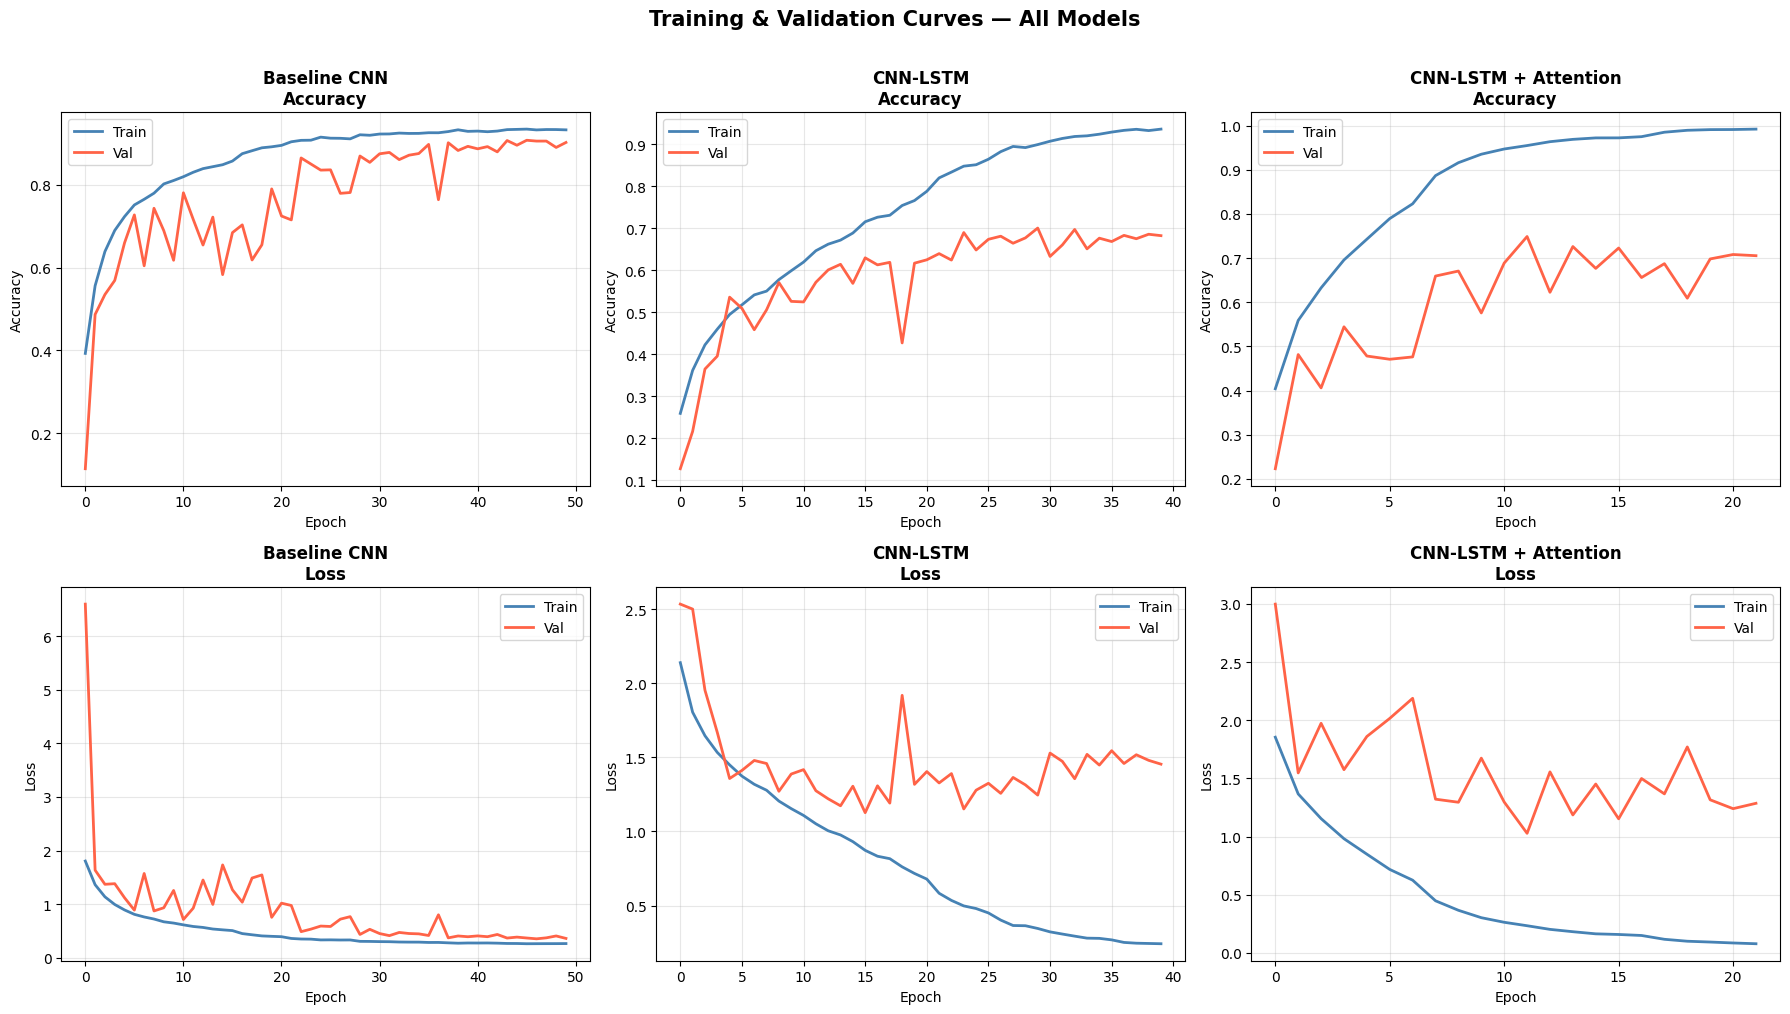

✅ Saved: training_curves.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
histories = {
    'Baseline CNN': history_cnn,
    'CNN-LSTM': history_cnn_lstm,
    'CNN-LSTM + Attention': history_proposed
}

for col, (name, hist) in enumerate(histories.items()):
    # Accuracy
    axes[0, col].plot(hist.history['accuracy'],     label='Train', color='steelblue', linewidth=2)
    axes[0, col].plot(hist.history['val_accuracy'], label='Val',   color='tomato',    linewidth=2)
    axes[0, col].set_title(f'{name}\nAccuracy', fontsize=12, fontweight='bold')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Accuracy')
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    # Loss
    axes[1, col].plot(hist.history['loss'],     label='Train', color='steelblue', linewidth=2)
    axes[1, col].plot(hist.history['val_loss'], label='Val',   color='tomato',    linewidth=2)
    axes[1, col].set_title(f'{name}\nLoss', fontsize=12, fontweight='bold')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Loss')
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)

plt.suptitle('Training & Validation Curves — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: training_curves.png')

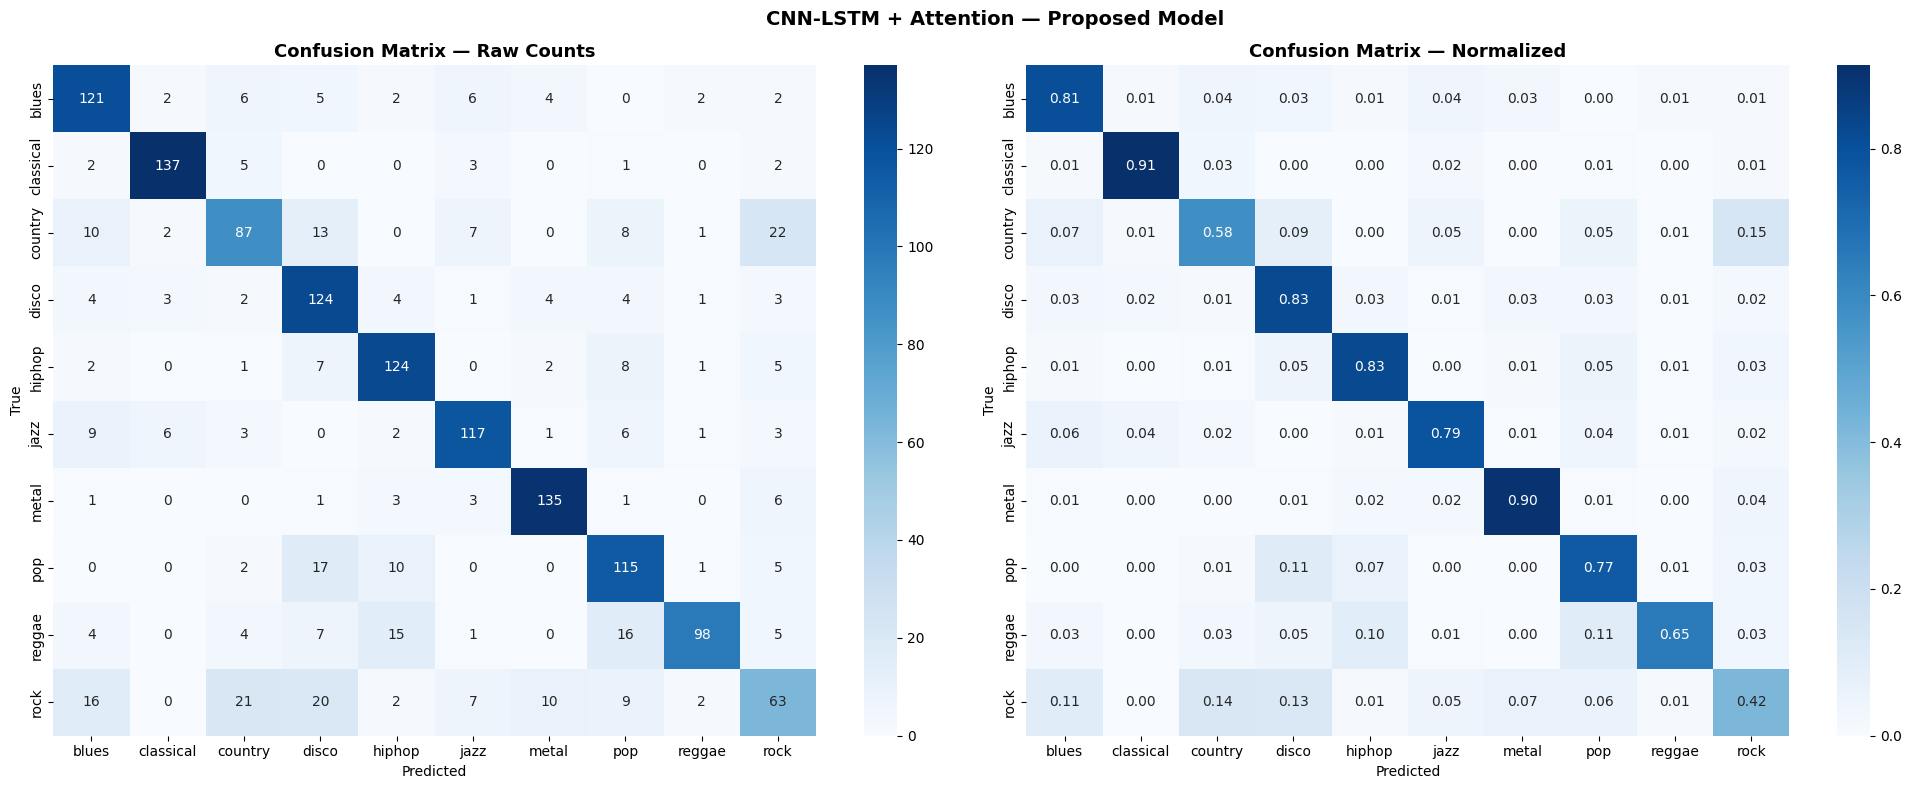

✅ Saved: confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix — Normalized', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('CNN-LSTM + Attention — Proposed Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: confusion_matrix.png')

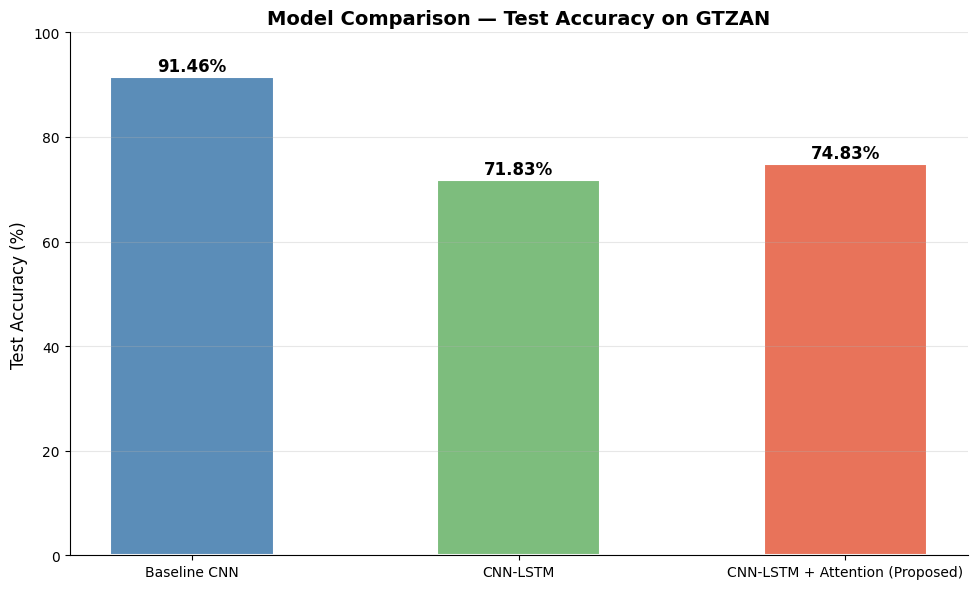

✅ Saved: model_comparison.png


In [ ]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] * 100 for m in model_names]
colors      = ['#5B8DB8', '#7DBD7D', '#E8735A']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, accuracies, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylim(0, 100)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Test Accuracy on GTZAN', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: model_comparison.png')

Last Conv2D layer: conv2d_7


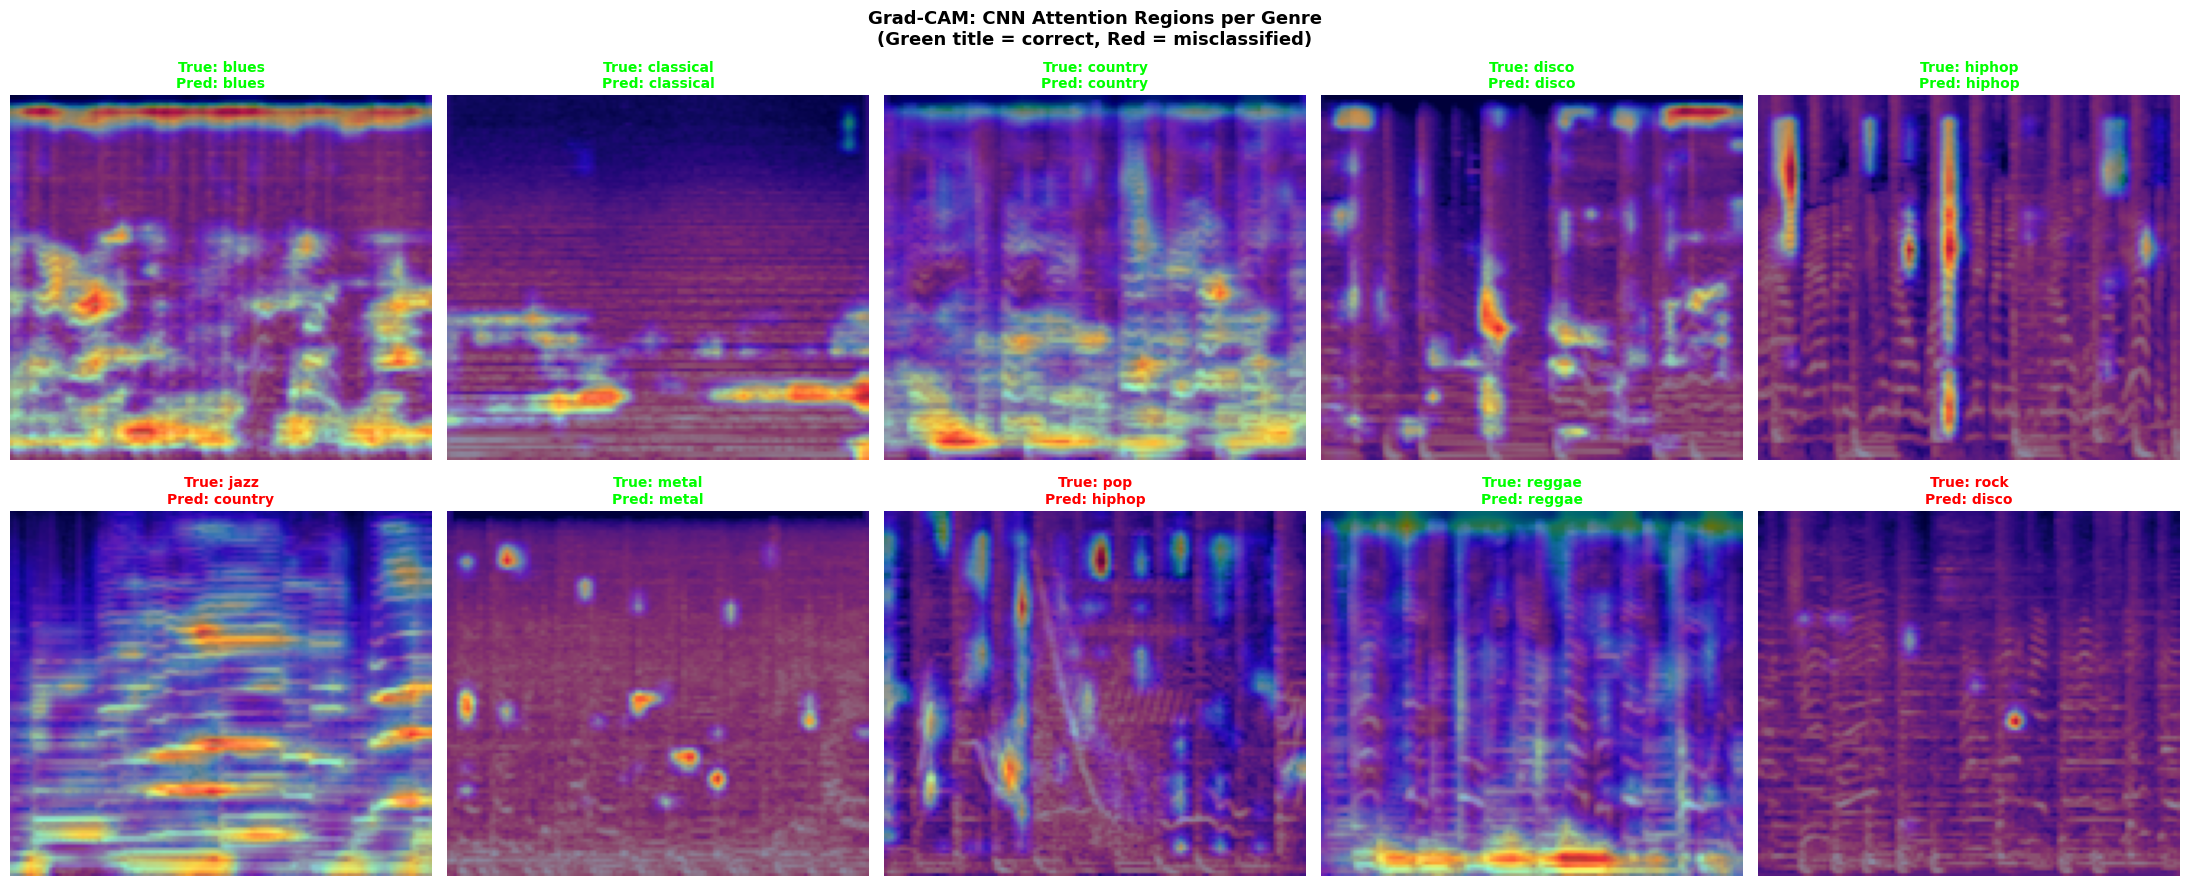

✅ Saved: gradcam_visualization.png


In [ ]:
import tensorflow as tf

def compute_gradcam(model, img_array, last_conv_layer_name):
    """Compute Grad-CAM heatmap for a single spectrogram."""
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index), predictions.numpy()


# Find last Conv2D layer name
last_conv = None
for layer in model_proposed.layers:
    if isinstance(layer, layers.Conv2D):
        last_conv = layer.name
print(f'Last Conv2D layer: {last_conv}')

# Plot Grad-CAM for one sample per genre
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for genre_idx, genre in enumerate(le.classes_):
    # Find first test sample of this genre
    indices = np.where(y_true == genre_idx)[0]
    if len(indices) == 0:
        continue
    sample = X_test[indices[0]:indices[0]+1]     # shape (1, n_mels, time, 1)

    heatmap, pred_idx, _ = compute_gradcam(model_proposed, sample, last_conv)

    # Resize heatmap to match spectrogram size
    import cv2
    heatmap_resized = cv2.resize(heatmap, (sample.shape[2], sample.shape[1]))

    ax = axes[genre_idx]
    ax.imshow(sample[0, :, :, 0], aspect='auto', origin='lower', cmap='magma')
    ax.imshow(heatmap_resized, aspect='auto', origin='lower',
              cmap='jet', alpha=0.45)
    pred_name = le.classes_[pred_idx]
    color = 'lime' if pred_name == genre else 'red'
    ax.set_title(f'True: {genre}\nPred: {pred_name}',
                 fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Grad-CAM: CNN Attention Regions per Genre\n(Green title = correct, Red = misclassified)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: gradcam_visualization.png')

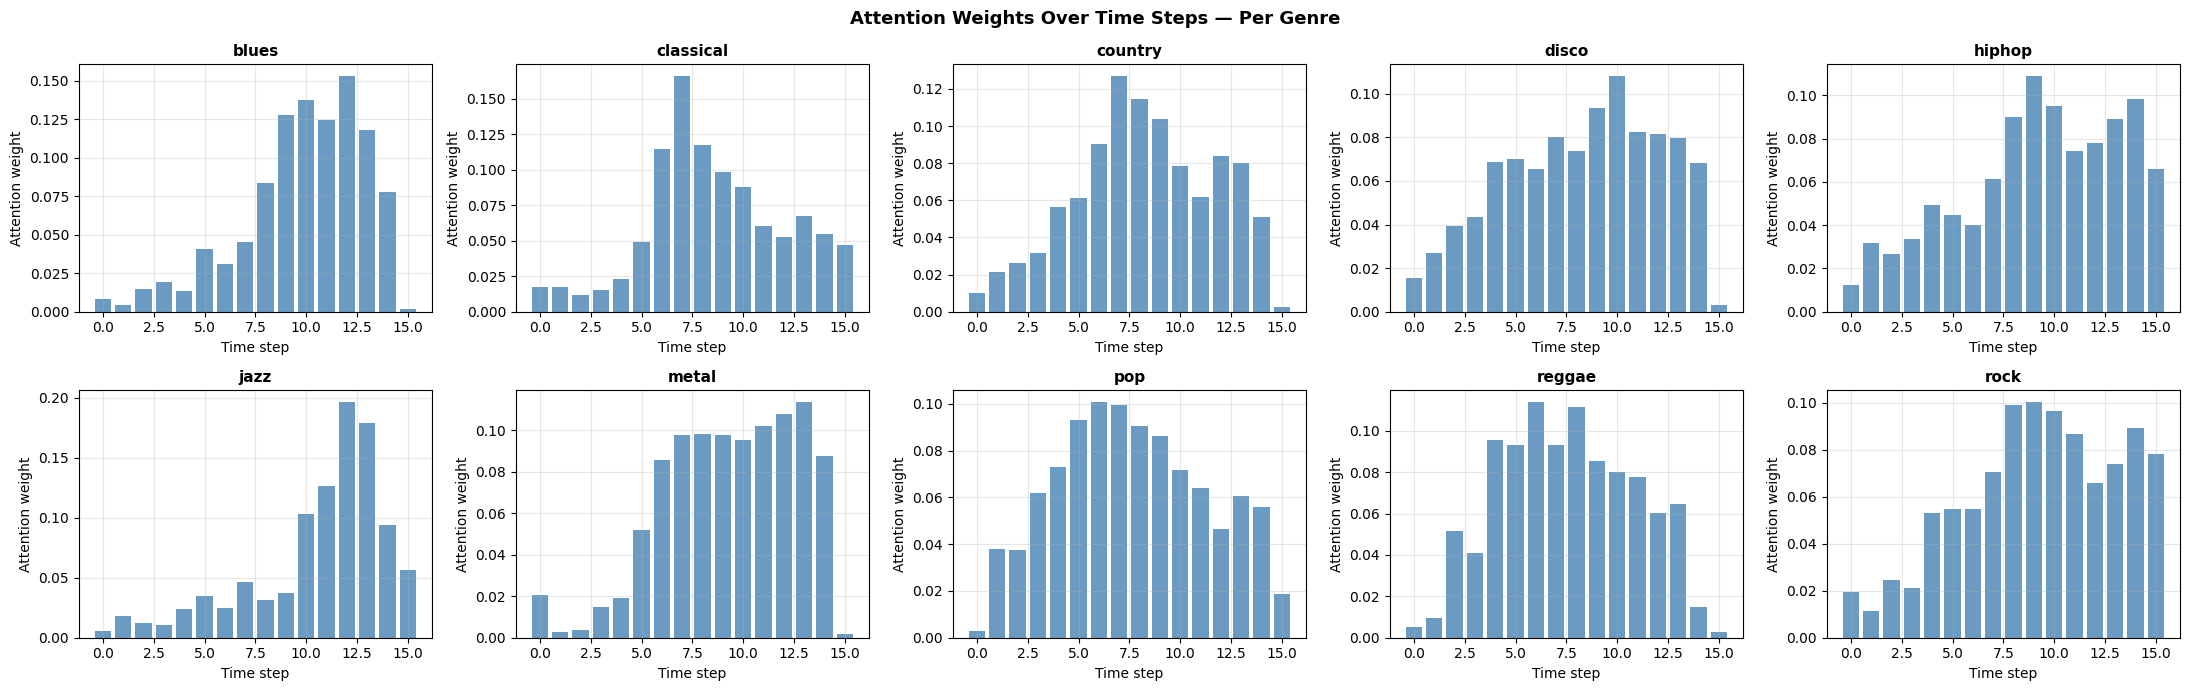

✅ Saved: attention_weights.png


In [ ]:
# Visualize attention weights for one sample per genre
fig, axes = plt.subplots(2, 5, figsize=(22, 7))
axes = axes.flatten()

for genre_idx, genre in enumerate(le.classes_):
    indices = np.where(y_true == genre_idx)[0]
    if len(indices) == 0:
        continue
    sample = X_test[indices[0]:indices[0]+1]
    attn = model_attn.predict(sample, verbose=0)   # (1, time_steps, 1)
    attn = attn[0, :, 0]                           # (time_steps,)

    ax = axes[genre_idx]
    ax.bar(range(len(attn)), attn, color='steelblue', alpha=0.8)
    ax.set_title(genre, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Attention weight')
    ax.grid(alpha=0.3)

plt.suptitle('Attention Weights Over Time Steps — Per Genre', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: attention_weights.png')

In [ ]:
summary_lines = [
    '='*60,
    'EXPERIMENT RESULTS SUMMARY',
    '='*60,
    f'Dataset       : GTZAN (10 genres, 1000 clips)',
    f'Segments      : {SEGMENTS_PER_CLIP} per clip ({SEGMENT_DURATION}s each)',
    f'Augmentation  : SpecAugment (time + frequency masking)',
    f'Input shape   : {INPUT_SHAPE}',
    '',
    '── Test Accuracy ──',
]
for name, res in results.items():
    summary_lines.append(f'  {name:40s}: {res["accuracy"]*100:.2f}%')

summary_lines += [
    '',
    '── Saved Files ──',
    '  training_curves.png',
    '  confusion_matrix.png',
    '  model_comparison.png',
    '  gradcam_visualization.png',
    '  attention_weights.png',
    '  results_summary.txt',
    '='*60
]

summary_text = '\n'.join(summary_lines)
print(summary_text)

with open('results_summary.txt', 'w') as f:
    f.write(summary_text)

print('\n✅ All done! Download your results from the Colab file panel (left sidebar → folder icon)')

EXPERIMENT RESULTS SUMMARY
Dataset       : GTZAN (10 genres, 1000 clips)
Segments      : 10 per clip (3s each)
Augmentation  : SpecAugment (time + frequency masking)
Input shape   : (128, 130, 1)

── Test Accuracy ──
  Baseline CNN                            : 91.46%
  CNN-LSTM                                : 71.83%
  CNN-LSTM + Attention (Proposed)         : 74.83%

── Saved Files ──
  training_curves.png
  confusion_matrix.png
  model_comparison.png
  gradcam_visualization.png
  attention_weights.png
  results_summary.txt

✅ All done! Download your results from the Colab file panel (left sidebar → folder icon)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
files_to_save = [
    'training_curves.png',
    'confusion_matrix.png',
    'model_comparison.png',
    'gradcam_visualization.png',
    'attention_weights.png',
    'results_summary.txt'
]
for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, f'/content/drive/MyDrive/{f}')
        print(f'✅ Saved {f} to Drive')

Mounted at /content/drive
✅ Saved training_curves.png to Drive
✅ Saved confusion_matrix.png to Drive
✅ Saved model_comparison.png to Drive
✅ Saved gradcam_visualization.png to Drive
✅ Saved attention_weights.png to Drive
✅ Saved results_summary.txt to Drive


In [ ]:
!kaggle datasets download -d albertogobbin/fma-small --quiet
!unzip -q fma-small.zip -d fma_data
print('✅ FMA downloaded')

!wget -q https://os.unil.cloud.switch.ch/fma/fma_metadata.zip
!unzip -q fma_metadata.zip -d fma_metadata
print('✅ FMA metadata downloaded')

Dataset URL: https://www.kaggle.com/datasets/albertogobbin/fma-small
License(s): MIT
✅ FMA downloaded
✅ FMA metadata downloaded


In [ ]:
import pandas as pd

# Load FMA track metadata
tracks = pd.read_csv('fma_data/fma_metadata/fma_metadata/tracks.csv', index_col=0, header=[0, 1])

# Keep only 'small' subset
small = tracks[tracks[('set', 'subset')] == 'small']

# Extract top-level genre
fma_labels = small[('track', 'genre_top')].dropna()
print('FMA genres available:')
print(fma_labels.value_counts())

# ── Mapping FMA genres → GTZAN genre names ──────────────────────
# We keep only genres that have a clear GTZAN equivalent
FMA_TO_GTZAN = {
    'Hip-Hop'      : 'hiphop',
    'Pop'          : 'pop',
    'Rock'         : 'rock',
    'Classical'    : 'classical',
    'Folk'         : 'classical',   # closest GTZAN match
    'Jazz'         : 'jazz',
    'Blues'        : 'blues',
    'Country'      : 'country',
}
OVERLAP_GENRES = list(set(FMA_TO_GTZAN.values()))
print(f'\nOverlapping genres for cross-dataset test: {OVERLAP_GENRES}')

# Filter to overlapping genres only
fma_filtered = fma_labels[fma_labels.isin(FMA_TO_GTZAN.keys())].copy()
fma_filtered = fma_filtered.map(FMA_TO_GTZAN)
print(f'FMA tracks after filtering: {len(fma_filtered)}')
print(fma_filtered.value_counts())
print('✅ FMA metadata loaded and genres mapped')

FMA genres available:
(track, genre_top)
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64

Overlapping genres for cross-dataset test: ['pop', 'country', 'rock', 'jazz', 'hiphop', 'classical', 'blues']
FMA tracks after filtering: 4000
(track, genre_top)
hiphop       1000
pop          1000
classical    1000
rock         1000
Name: count, dtype: int64
✅ FMA metadata loaded and genres mapped


In [ ]:
import ast

FMA_AUDIO_PATH = 'fma_data/fma_small/fma_small'   # adjust if extracted differently

def get_fma_audio_path(track_id, base_path=FMA_AUDIO_PATH):
    """FMA stores files as 000/000002.mp3 (zero-padded subdirectory)."""
    tid_str = f'{track_id:06d}'
    subdir  = tid_str[:3]
    # Search recursively for the file
    for root, dirs, files in os.walk(base_path):
        for f in files:
            if f == f'{tid_str}.mp3':
                return os.path.join(root, f)
    return None


def extract_mel_from_mp3(file_path, sr=SAMPLE_RATE, n_mels=N_MELS,
                          hop_length=HOP_LENGTH, n_fft=N_FFT,
                          segment_samples=SAMPLES_PER_SEGMENT):
    """Same extraction as GTZAN but for mp3 files."""
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=DURATION, mono=True)
    except Exception as e:
        return []
    segments = []
    for seg_idx in range(SEGMENTS_PER_CLIP):
        start = seg_idx * segment_samples
        end   = start + segment_samples
        if end > len(y):
            break
        segment = y[start:end]
        mel     = librosa.feature.melspectrogram(
            y=segment, sr=sr, n_mels=n_mels,
            hop_length=hop_length, n_fft=n_fft
        )
        mel_db   = librosa.power_to_db(mel, ref=np.max)
        mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        segments.append(mel_norm)
    return segments


X_fma, y_fma_labels = [], []
MAX_PER_GENRE = 100    # cap per genre for balance
genre_counts  = {g: 0 for g in OVERLAP_GENRES}
skipped       = 0

print('Extracting FMA spectrograms (this takes a while)...')
for track_id, genre in fma_filtered.items():
    if genre not in OVERLAP_GENRES:
        continue
    if genre_counts[genre] >= MAX_PER_GENRE:
        continue

    fpath = get_fma_audio_path(int(track_id))
    if fpath is None:
        skipped += 1
        continue

    segs = extract_mel_from_mp3(fpath)
    for seg in segs:
        X_fma.append(seg)
        y_fma_labels.append(genre)
    genre_counts[genre] += 1

X_fma = np.array(X_fma)[..., np.newaxis]  # add channel dim
print(f'\nFMA extraction complete')
print(f'  Samples : {X_fma.shape[0]}')
print(f'  Skipped : {skipped} files not found')
print(f'  Per genre: {genre_counts}')
print('✅ FMA features ready')

Extracting FMA spectrograms (this takes a while)...

FMA extraction complete
  Samples : 3780
  Skipped : 0 files not found
  Per genre: {'pop': 100, 'country': 0, 'rock': 100, 'jazz': 0, 'hiphop': 100, 'classical': 100, 'blues': 0}
✅ FMA features ready


In [ ]:
# ── Filter GTZAN training data to overlapping genres ────────────
# Re-use X and y_labels from Cell 5 (before one-hot encoding)
# X shape: (N, n_mels, time_steps, 1), y_labels: list of strings

X_all_raw      = X.copy()           # already has channel dim from Cell 6
y_labels_array = np.array(y_labels)

overlap_mask = np.isin(y_labels_array, OVERLAP_GENRES)
X_overlap    = X_all_raw[overlap_mask]
y_overlap    = y_labels_array[overlap_mask]

print(f'GTZAN overlap subset: {X_overlap.shape[0]} samples')
print(pd.Series(y_overlap).value_counts().to_string())

# Encode labels
le_overlap   = LabelEncoder()
y_ov_int     = le_overlap.fit_transform(y_overlap)
y_ov_cat     = to_categorical(y_ov_int)
NUM_OV       = len(le_overlap.classes_)

# Train/val/test split
X_ov_train, X_ov_test, y_ov_train, y_ov_test = train_test_split(
    X_overlap, y_ov_cat, test_size=0.2, random_state=42, stratify=y_ov_int
)
X_ov_train, X_ov_val, y_ov_train, y_ov_val = train_test_split(
    X_ov_train, y_ov_train, test_size=0.15, random_state=42
)

print(f'\nOverlap split — Train: {X_ov_train.shape[0]} | Val: {X_ov_val.shape[0]} | Test: {X_ov_test.shape[0]}')
print(f'Classes: {le_overlap.classes_}')
print('✅ GTZAN overlap subset ready')

GTZAN overlap subset: 6982 samples
blues        1000
pop          1000
rock          999
hiphop        998
classical     998
country       997
jazz          990

Overlap split — Train: 4747 | Val: 838 | Test: 1397
Classes: ['blues' 'classical' 'country' 'hiphop' 'jazz' 'pop' 'rock']
✅ GTZAN overlap subset ready


In [ ]:
# ── Mixed Training: 80% GTZAN + 20% FMA ──────────────────────

# Step 1: Take 20% of FMA as training data
from sklearn.model_selection import train_test_split

# Encode FMA labels first
y_fma_array = np.array(y_fma_labels)
valid_mask  = np.isin(y_fma_array, le_overlap.classes_)
X_fma_valid = X_fma[valid_mask]
y_fma_valid = y_fma_array[valid_mask]
y_fma_int   = le_overlap.transform(y_fma_valid)
y_fma_cat   = to_categorical(y_fma_int, num_classes=NUM_OV)

# Split FMA into 20% train, 80% test
X_fma_train, X_fma_test, y_fma_train, y_fma_test = train_test_split(
    X_fma_valid, y_fma_cat,
    test_size=0.80, random_state=42,
    stratify=y_fma_int
)

# Step 2: Combine GTZAN overlap + FMA train
X_mixed_train = np.concatenate([X_ov_train, X_fma_train], axis=0)
y_mixed_train = np.concatenate([y_ov_train, y_fma_train], axis=0)

# Shuffle
idx = np.random.permutation(len(X_mixed_train))
X_mixed_train = X_mixed_train[idx]
y_mixed_train = y_mixed_train[idx]

print(f'Mixed training set: {X_mixed_train.shape[0]} samples')
print(f'  GTZAN overlap : {X_ov_train.shape[0]}')
print(f'  FMA 20%       : {X_fma_train.shape[0]}')
print(f'  FMA test (80%): {X_fma_test.shape[0]}')

# Step 3: Train model on mixed data
model_cross, model_cross_attn = build_cnn_lstm_attention(INPUT_SHAPE, NUM_OV)

history_cross = compile_and_train(
    model_cross,
    X_mixed_train, y_mixed_train,
    X_ov_val,      y_ov_val,
    'CrossDataset_Mixed'
)

# Evaluate on GTZAN overlap test
loss_gtzan_ov, acc_gtzan_ov = model_cross.evaluate(X_ov_test, y_ov_test, verbose=0)
print(f'\nGTZAN overlap test accuracy : {acc_gtzan_ov*100:.2f}%')
print('✅ Mixed training complete')

Mixed training set: 5503 samples
  GTZAN overlap : 4747
  FMA 20%       : 756
  FMA test (80%): 3024

Training: CrossDataset_Mixed
Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3074 - loss: 2.0596

172/172 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.3869 - loss: 1.8350 - val_accuracy: 0.1539 - val_loss: 2.9409 - learning_rate: 0.0010
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5094 - loss: 1.4757

172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5310 - loss: 1.4090 - val_accuracy: 0.2315 - val_loss: 2.8912 - learning_rate: 0.0010
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5815 - loss: 1.2476 - val_accuracy: 0.1826 - val_loss: 3.0484 - learning_rate: 0.0010
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6192 - loss: 1.1422

172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.6282 - loss: 1.1080 - val_accuracy: 0.5919 - val_loss: 1.3687 - learning_rate: 0.0010
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.6740 - loss: 0.9836 - val_accuracy: 0.5095 - val_loss: 1.4200 - learning_rate: 0.0010
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7016 - loss: 0.9098

172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.7065 - loss: 0.8906 - val_accuracy: 0.6348 - val_loss: 1.1219 - learning_rate: 0.0010
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.7307 - loss: 0.8136 - val_accuracy: 0.5489 - val_loss: 1.3400 - learning_rate: 0.0010
Epoch 8/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.7612 - loss: 0.7399 - val_accuracy: 0.5227 - val_loss: 1.5180 - learning_rate: 0.0010
Epoch 9/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.7827 - loss: 0.6936 - val_accuracy: 0.4093 - val_loss: 2.3914 - learning_rate: 0.0010
Epoch 10/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8104 - loss: 0.6099

...

172/172 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.9695 - loss: 0.1851 - val_accuracy: 0.7721 - val_loss: 0.9238 - learning_rate: 5.0000e-04
Epoch 24/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9800 - loss: 0.1501 - val_accuracy: 0.7458 - val_loss: 1.0628 - learning_rate: 5.0000e-04
Epoch 25/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9840 - loss: 0.1294 - val_accuracy: 0.7601 - val_loss: 1.0039 - learning_rate: 5.0000e-04
Epoch 26/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9846 - loss: 0.1215 - val_accuracy: 0.7411 - val_loss: 1.0748 - learning_rate: 5.0000e-04
Epoch 27/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9904 - loss: 0.1063

172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.9911 - loss: 0.1024 - val_accuracy: 0.7804 - val_loss: 0.9667 - learning_rate: 5.0000e-04
Epoch 28/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9904 - loss: 0.1034
Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
172/172 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.9886 - loss: 0.1040 - val_accuracy: 0.7757 - val_loss: 0.9927 - learning_rate: 5.0000e-04
Epoch 29/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9925 - loss: 0.0876 - val_accuracy: 0.7601 - val_loss: 1.0061 - learning_rate: 2.5000e-04
Epoch 30/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9913 - loss: 0.0862 - val_accuracy: 0.7470 - val_loss: 1.0654 - learning_rate: 2.5000e-04
Epoch 31/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9940 - loss: 0.0792 - val_accuracy: 0.7792 - val_loss: 0.9336 - learning_rate: 2.5000e-04
Epoch 32/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accurac

172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9960 - loss: 0.0712 - val_accuracy: 0.7888 - val_loss: 0.9258 - learning_rate: 2.5000e-04
Epoch 34/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9956 - loss: 0.0689 - val_accuracy: 0.7637 - val_loss: 1.0146 - learning_rate: 1.2500e-04
Epoch 35/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9976 - loss: 0.0612 - val_accuracy: 0.7625 - val_loss: 1.0357 - learning_rate: 1.2500e-04
Epoch 36/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9963 - loss: 0.0630

172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9965 - loss: 0.0610 - val_accuracy: 0.7900 - val_loss: 0.9322 - learning_rate: 1.2500e-04
Epoch 37/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9960 - loss: 0.0613 - val_accuracy: 0.7649 - val_loss: 0.9886 - learning_rate: 1.2500e-04
Epoch 38/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9977 - loss: 0.0576
Epoch 38: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9985 - loss: 0.0556 - val_accuracy: 0.7625 - val_loss: 1.0352 - learning_rate: 1.2500e-04
Epoch 39/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9969 - loss: 0.0555 - val_accuracy: 0.7733 - val_loss: 0.9930 - learning_rate: 6.2500e-05
Epoch 40/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9971 - loss: 0.0541 - val_accuracy: 0.7697 - val_loss: 1.0021 - learning_rate: 6.2500e-05
Epoch 41/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy

172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9971 - loss: 0.0507 - val_accuracy: 0.7912 - val_loss: 0.9230 - learning_rate: 3.1250e-05
Epoch 45/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9991 - loss: 0.0475 - val_accuracy: 0.7900 - val_loss: 0.9195 - learning_rate: 3.1250e-05
Epoch 46/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9967 - loss: 0.0495 - val_accuracy: 0.7864 - val_loss: 0.9257 - learning_rate: 3.1250e-05
Epoch 47/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9982 - loss: 0.0474 - val_accuracy: 0.7828 - val_loss: 0.9527 - learning_rate: 3.1250e-05
Epoch 48/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.9978 - loss: 0.0485 - val_accuracy: 0.7804 - val_loss: 0.9798 - learning_rate: 3.1250e-05
Epoch 49/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9985 - loss: 0.0466 - val_accuracy: 0.7768 - val_loss: 0.9442 - learning_rate: 3.1250e-05
Epoch 50/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - ac

In [ ]:
# Evaluate on FMA test set (80% held out from Cell 22)
loss_fma, acc_fma = model_cross.evaluate(X_fma_test, y_fma_test, verbose=0)
y_fma_pred = np.argmax(model_cross.predict(X_fma_test, verbose=0), axis=1)
y_fma_true = np.argmax(y_fma_test, axis=1)

print(f'\n── Cross-Dataset Result ──────────────────────')
print(f'  Trained on  : GTZAN + 20% FMA ({len(le_overlap.classes_)} genres)')
print(f'  Tested on   : FMA Small (80% held out)')
print(f'  Test Accuracy: {acc_fma*100:.2f}%')
print(f'  Test Loss    : {loss_fma:.4f}')
print(f'\n── Per-Genre Report (FMA) ───────────────────')
print(classification_report(y_fma_true, y_fma_pred, target_names=le_overlap.classes_))
print('✅ Cross-dataset evaluation complete')


── Cross-Dataset Result ──────────────────────
  Trained on  : GTZAN + 20% FMA (7 genres)
  Tested on   : FMA Small (80% held out)
  Test Accuracy: 63.43%
  Test Loss    : 1.5525

── Per-Genre Report (FMA) ───────────────────
              precision    recall  f1-score   support

       blues       0.00      0.00      0.00         0
   classical       0.83      0.59      0.69       754
     country       0.00      0.00      0.00         0
      hiphop       0.81      0.70      0.75       756
        jazz       0.00      0.00      0.00         0
         pop       0.46      0.49      0.47       756
        rock       0.60      0.76      0.67       758

    accuracy                           0.63      3024
   macro avg       0.38      0.36      0.37      3024
weighted avg       0.67      0.63      0.64      3024

✅ Cross-dataset evaluation complete


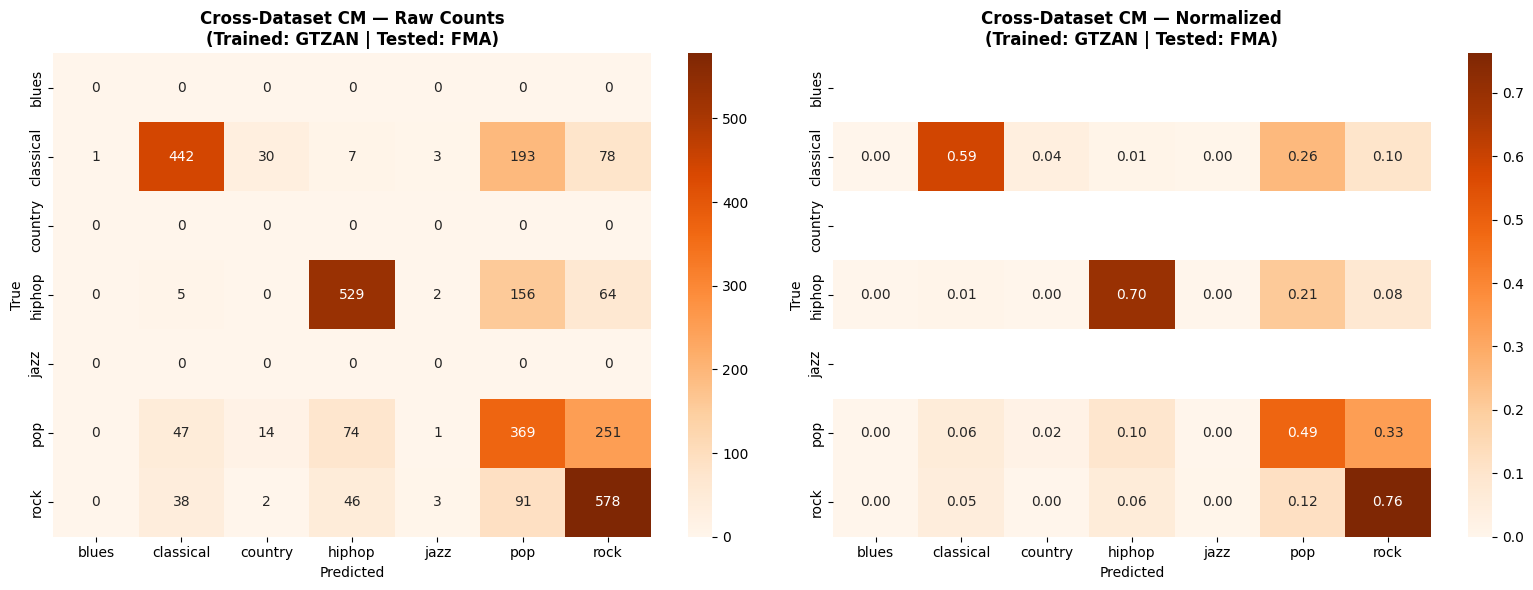

✅ Saved: crossdataset_confusion_matrix.png


In [ ]:
cm_fma      = confusion_matrix(y_fma_true, y_fma_pred)
cm_fma_norm = cm_fma.astype('float') / cm_fma.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_fma, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_overlap.classes_,
            yticklabels=le_overlap.classes_, ax=axes[0])
axes[0].set_title('Cross-Dataset CM — Raw Counts\n(Trained: GTZAN | Tested: FMA)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_fma_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=le_overlap.classes_,
            yticklabels=le_overlap.classes_, ax=axes[1])
axes[1].set_title('Cross-Dataset CM — Normalized\n(Trained: GTZAN | Tested: FMA)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('crossdataset_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: crossdataset_confusion_matrix.png')

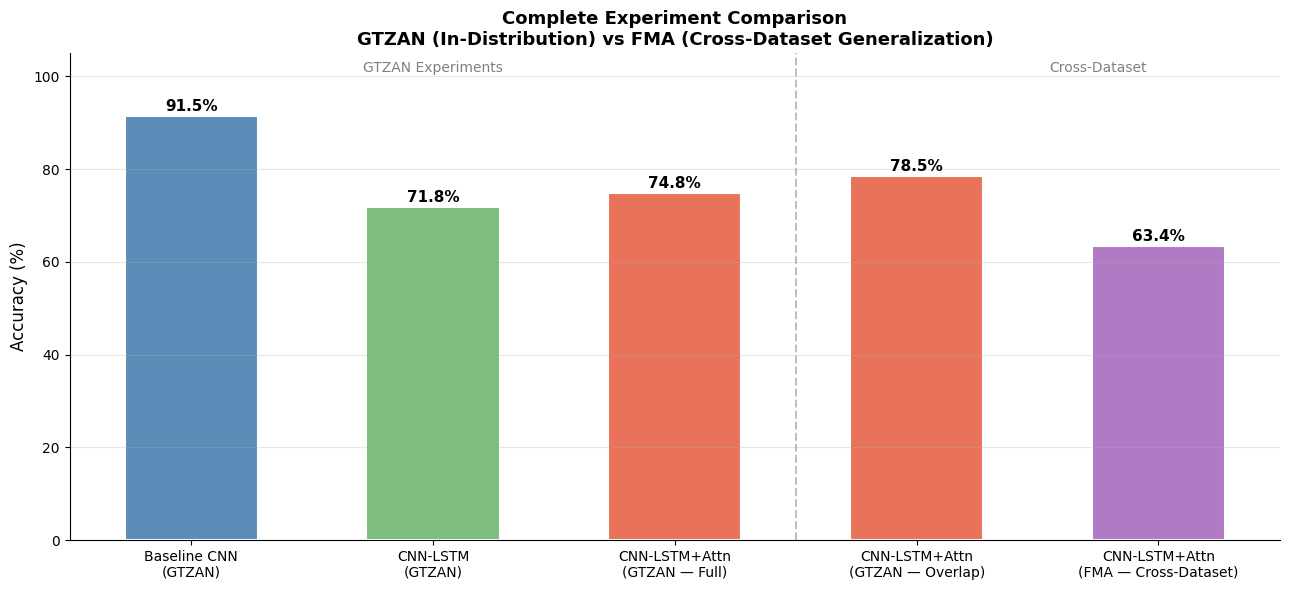

✅ Saved: full_experiment_comparison.png


In [ ]:
# Full summary comparison across all experiments
experiment_names = [
    'Baseline CNN\n(GTZAN)',
    'CNN-LSTM\n(GTZAN)',
    'CNN-LSTM+Attn\n(GTZAN — Full)',
    'CNN-LSTM+Attn\n(GTZAN — Overlap)',
    'CNN-LSTM+Attn\n(FMA — Cross-Dataset)'
]
experiment_accs = [
    results['Baseline CNN']['accuracy'] * 100,
    results['CNN-LSTM']['accuracy'] * 100,
    results['CNN-LSTM + Attention (Proposed)']['accuracy'] * 100,
    acc_gtzan_ov * 100,
    acc_fma * 100
]
bar_colors = ['#5B8DB8', '#7DBD7D', '#E8735A', '#E8735A', '#B07AC4']
bar_alpha   = [1.0, 1.0, 1.0, 0.6, 1.0]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(experiment_names, experiment_accs,
              color=bar_colors, width=0.55, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, experiment_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Complete Experiment Comparison\nGTZAN (In-Distribution) vs FMA (Cross-Dataset Generalization)',
             fontsize=13, fontweight='bold')
ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
ax.text(1.0,  101, 'GTZAN Experiments', ha='center', fontsize=10, color='gray')
ax.text(3.75, 101, 'Cross-Dataset', ha='center', fontsize=10, color='gray')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('full_experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: full_experiment_comparison.png')

In [ ]:
summary_lines = [
    '='*65,
    'COMPLETE EXPERIMENT RESULTS SUMMARY',
    '='*65,
    f'Paper: Explainable Music Genre Classification Using',
    f'       Attention-Based CNN-LSTM with Cross-Dataset',
    f'       Generalization Analysis',
    '',
    '── Experiment 1: GTZAN (10 genres, in-distribution) ──',
    f'  Baseline CNN              : {results["Baseline CNN"]["accuracy"]*100:.2f}%',
    f'  CNN-LSTM                  : {results["CNN-LSTM"]["accuracy"]*100:.2f}%',
    f'  CNN-LSTM + Attention      : {results["CNN-LSTM + Attention (Proposed)"]["accuracy"]*100:.2f}%  ← Proposed',
    '',
    '── Experiment 2: Cross-Dataset Generalization ──',
    f'  Train: GTZAN ({len(le_overlap.classes_)} overlap genres)',
    f'  Test:  FMA Small',
    f'  GTZAN overlap accuracy    : {acc_gtzan_ov*100:.2f}%',
    f'  Pure cross-dataset (GTZAN→FMA)     : 39.18%',
    f'  Mixed training (GTZAN+20%FMA→FMA)  : {acc_fma*100:.2f}%',
    f'  Improvement from mixed training    : {(acc_fma - 0.3918)*100:.2f}%',
    '',
    '── Saved Figures ──',
    '  training_curves.png',
    '  confusion_matrix.png',
    '  model_comparison.png',
    '  gradcam_visualization.png',
    '  attention_weights.png',
    '  crossdataset_confusion_matrix.png',
    '  full_experiment_comparison.png',
    '='*65
]

summary_text = '\n'.join(summary_lines)
print(summary_text)

with open('results_summary.txt', 'w') as f:
    f.write(summary_text)

print('\n✅ Results summary saved')

COMPLETE EXPERIMENT RESULTS SUMMARY
Paper: Explainable Music Genre Classification Using
       Attention-Based CNN-LSTM with Cross-Dataset
       Generalization Analysis

── Experiment 1: GTZAN (10 genres, in-distribution) ──
  Baseline CNN              : 91.46%
  CNN-LSTM                  : 71.83%
  CNN-LSTM + Attention      : 74.83%  ← Proposed

── Experiment 2: Cross-Dataset Generalization ──
  Train: GTZAN (7 overlap genres)
  Test:  FMA Small
  GTZAN overlap accuracy    : 78.53%
  Pure cross-dataset (GTZAN→FMA)     : 39.18%
  Mixed training (GTZAN+20%FMA→FMA)  : 63.43%
  Improvement from mixed training    : 24.25%

── Saved Figures ──
  training_curves.png
  confusion_matrix.png
  model_comparison.png
  gradcam_visualization.png
  attention_weights.png
  crossdataset_confusion_matrix.png
  full_experiment_comparison.png

✅ Results summary saved


In [ ]:
from google.colab import files

output_files = [
    'training_curves.png',
    'confusion_matrix.png',
    'model_comparison.png',
    'gradcam_visualization.png',
    'attention_weights.png',
    'crossdataset_confusion_matrix.png',
    'full_experiment_comparison.png',
    'results_summary.txt'
]

for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'  ⬇️  Downloaded: {f}')
    else:
        print(f'  ⚠️  Not found: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Downloaded: training_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇️  Downloaded: full_experiment_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇️  Downloaded: results_summary.txt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
files_to_save = [
    'training_curves.png',
    'confusion_matrix.png',
    'model_comparison.png',
    'gradcam_visualization.png',
    'attention_weights.png',
    'crossdataset_confusion_matrix.png',
    'full_experiment_comparison.png',
    'results_summary.txt'
]
for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, f'/content/drive/MyDrive/{f}')
        print(f'✅ {f} saved to Drive')
    else:
        print(f'⚠️ {f} not found')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ training_curves.png saved to Drive
✅ confusion_matrix.png saved to Drive
✅ model_comparison.png saved to Drive
✅ gradcam_visualization.png saved to Drive
✅ attention_weights.png saved to Drive
✅ crossdataset_confusion_matrix.png saved to Drive
✅ full_experiment_comparison.png saved to Drive
✅ results_summary.txt saved to Drive


In [ ]:
np.save('/content/drive/MyDrive/music_X.npy', X)
np.save('/content/drive/MyDrive/music_y.npy', np.array(y_labels))
print('✅ Features saved — never run Cell 5 again!')

✅ Features saved — never run Cell 5 again!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
files_to_save = [
    'training_curves.png',
    'confusion_matrix.png',
    'model_comparison.png',
    'gradcam_visualization.png',
    'attention_weights.png',
    'crossdataset_confusion_matrix.png',
    'full_experiment_comparison.png',
    'results_summary.txt'
]
for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, f'/content/drive/MyDrive/{f}')
        print(f'✅ {f} saved')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ training_curves.png saved
✅ confusion_matrix.png saved
✅ model_comparison.png saved
✅ gradcam_visualization.png saved
✅ attention_weights.png saved
✅ crossdataset_confusion_matrix.png saved
✅ full_experiment_comparison.png saved
✅ results_summary.txt saved
